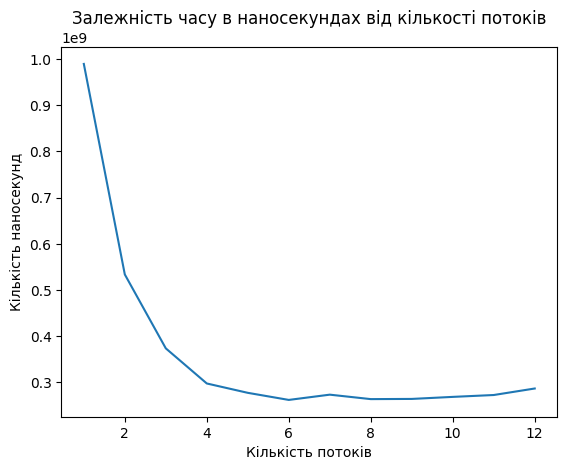

In [27]:
import typing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

count_words_single = pd.read_csv('count_words_single.csv')
count_words_multi = pd.read_csv('count_words_multi.csv')

count_words_data = count_words_multi.groupby(['threads_count']).mean()
count_words_data.loc[1] = count_words_single.mean()
count_words_data = count_words_data.sort_index()

fig, axes = plt.subplots(1)
axes.set_xlabel('Кількість потоків')
axes.set_ylabel('Кількість наносекунд')
axes.set_title('Залежність часу в наносекундах від кількості потоків')
axes.plot(count_words_data.index, count_words_data.values)

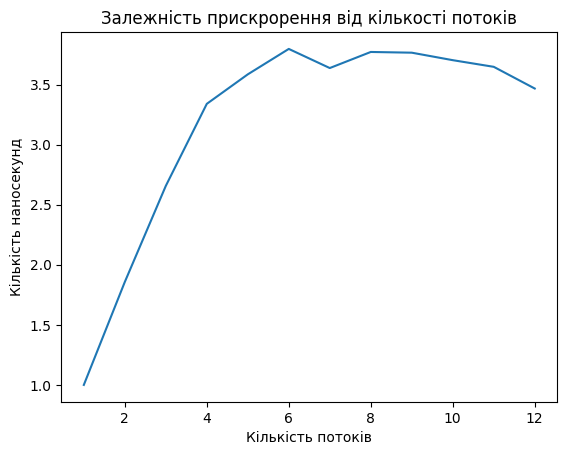

In [28]:
count_words_data /= count_words_data.loc[1]
count_words_data = 1.0 / count_words_data
fig, axes = plt.subplots(1)
axes.set_xlabel('Кількість потоків')
axes.set_ylabel('Кількість наносекунд')
axes.set_title('Залежність прискрорення від кількості потоків')
axes.plot(count_words_data.index, count_words_data.values)

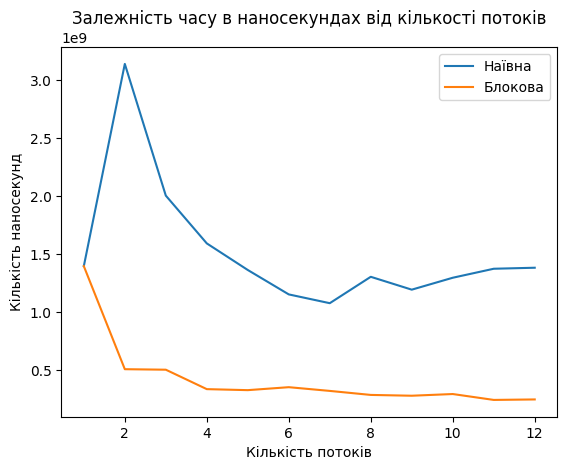

In [29]:
import typing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_single = pd.read_csv('matrix_transpose_single.csv')
data_multi = pd.read_csv('matrix_transpose_multi.csv')
data_block = pd.read_csv('matrix_transpose_block.csv')

data_multi = data_multi.groupby(['threads_count']).mean()
data_block = data_block.groupby(['threads_count']).mean()

data_multi.loc[1] = data_single.mean()
data_multi = data_multi.sort_index()

data_block.loc[1] = data_single.mean()
data_block = data_block.sort_index()

fig, axes = plt.subplots(1)
axes.set_xlabel('Кількість потоків')
axes.set_ylabel('Кількість наносекунд')
axes.plot(data_multi.index, data_multi.values, label='Наївна')
axes.plot(data_block.index, data_block.values, label='Блокова')
axes.set_title('Залежність часу в наносекундах від кількості потоків')
axes.legend()

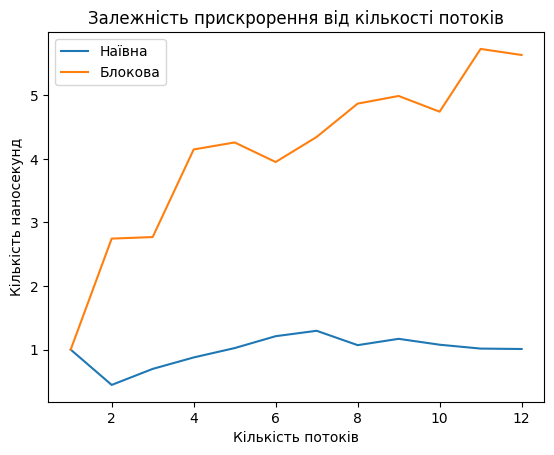

In [30]:
data_multi /= data_multi.loc[1]
data_multi = 1.0 / data_multi

data_block /= data_block.loc[1]
data_block = 1.0 / data_block

fig, axes = plt.subplots(1)
axes.set_xlabel('Кількість потоків')
axes.set_ylabel('Кількість наносекунд')
axes.plot(data_multi.index, data_multi.values, label='Наївна')
axes.plot(data_block.index, data_block.values, label='Блокова')
axes.set_title('Залежність прискрорення від кількості потоків')
axes.legend()

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

data_single = pd.read_csv('pi_monte_single.csv')
data_multi = pd.read_csv('pi_monte_multi.csv')
data_multi['points_count'] = data_multi['points_per_thread'] * data_multi['threads_count']
del data_multi['points_per_thread']

data_single['threads_count'] = 1

data_multi = data_multi[['threads_count', 'points_count', 'nanoseconds']]
data_single = data_single[['threads_count', 'points_count', 'nanoseconds']]

data_multi.groupby(['threads_count', 'points_count']).mean()

nanoseconds
threads_count points_count             
2             2000000         3017985.2
              4000000         5673786.1
              6000000         8692319.3
              8000000        11333265.1
              10000000       14095783.7
...                                 ...
12            72000000       29521541.7
              84000000       35458870.5
              96000000       73363652.9
              108000000      85698218.8
              120000000      98134051.8

[110 rows x 1 columns]